In [1]:
import json 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
def process_single_text(text): 
    if isinstance(text, dict): 
        # in case of phi 
        text = text["content"]
    if "{" in text and "}" in text: 
        json_start = text.split("{")[1] # select the first part 
        json_full = json_start.split("}")[0]
        loaded_json = None
        try: 
            # load json 
            json_full = "{" + json_full + "}"
            loaded_json = json.loads(json_full)
        except Exception: 
            # print(f"could not load json: {json_full}")
            return None 
        if "final answer" in loaded_json: 
            result = loaded_json["final answer"]
            return result.strip().lower()
        return None 
    return None

In [3]:
from collections import Counter
def process_outputs(file): 
    emotion_dict = {
        "happiness": [],
        "surprise": [],
        "pride": [],
        "interest": [],
        "hope": [], 
        "boredom": [],
        "disgust": [],
        "contempt": [],
        "guilt": [],
        "fear": [], 
        "shame": [], 
        "sadness": [],
        "anger": [],
        "challenge": [],
        "frustration": []
    }
    dimension_list = ['effort', 'enjoyment', 'fairness', 'other responsibility', 'attention', 'situational control', 'understand', 'certainty', 'self responsibility', 'pleasantness', 'obstacle', 'self control', 'other control']
    dimension_dict = {}
    for dimension in dimension_list: 
        dimension_dict[dimension] = 0

    with open(file, "r") as f: 
        for line in f.readlines(): 
            curr_line = json.loads(line)
            id = curr_line["id"]
            processed_output = process_single_text(curr_line["output"])
            # print(processed_output)
            if not processed_output:
                continue
            emotion_name = id.split("_")[0]
            emotion_dict[emotion_name].append(processed_output)
    
    # calculate frequency: 
    for key, responses in emotion_dict.items(): 
        for val in responses: 
            dimension_dict[val] = dimension_dict.get(val, 0) + 1
    
    return (dict(sorted(dimension_dict.items(), key=lambda x:x[1], reverse=True)))


In [4]:
dimension_list = ['effort', 'enjoyment', 'fairness', 'other responsibility', 'attention', 'situational control', 'understand', 'certainty', 'self responsibility', 'pleasantness', 'obstacle', 'self control', 'other control']

In [5]:
def get_attribution_percentage(file):
    output_dict = process_outputs(file)
    cleaned_dict = {}
    for key, value in output_dict.items(): 
        if key in dimension_list: 
            cleaned_dict[key] = value

    percentage_dict = {} 
    total = sum(list(cleaned_dict.values()))

    for key, value in cleaned_dict.items(): 
        percentage_dict[key] = round(cleaned_dict[key] / total, 3) 
    
    return dict(sorted(percentage_dict.items(), key = lambda x: x[1], reverse=True))    

In [6]:
gpt_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gpt_explicit_cog_reason.jsonl")
print(gpt_dict)
gpt_dict_clubbed = {
    "responsibility": 0.23, 
    "certainty": 0.139, 
    "problem": 0.128, 
    "fairness": 0.12, 
    "pleasantness": 0.179, 
    "engagement": 0.047, 
    "understand": 0.044, 
    "control": 0.091,
    "effort": 0.022
}

{'self responsibility': 0.175, 'certainty': 0.139, 'obstacle': 0.128, 'fairness': 0.12, 'pleasantness': 0.106, 'enjoyment': 0.073, 'other responsibility': 0.055, 'attention': 0.047, 'understand': 0.044, 'self control': 0.044, 'situational control': 0.036, 'effort': 0.022, 'other control': 0.011}


In [7]:
llama_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_explicit_cog_reason.jsonl")
print(llama_dict)
llama_dict_clubbed = {
    "responsibility": 0, 
    "control": 0, 
    "problem": 0,
    "fairness": 0, 
    "pleasantness": 0,
    "engagement": 0,
    "certainty": 0,
    "understand": 0, 
    "effort": 0
}

for key, value in llama_dict.items(): 
    if "responsibility" in key: 
        llama_dict_clubbed["responsibility"] += value 
    elif "control" in key: 
        llama_dict_clubbed["control"] += value 
    elif "problem" in key or "obstacle" in key: 
        llama_dict_clubbed["problem"] += value 
    elif "fairness" in key or "cheated" in key: 
        llama_dict_clubbed["fairness"] += value 
    elif "pleasantness" in key or "enjoyment" in key:
        llama_dict_clubbed["pleasantness"] += value 
    elif "attention" in key or "consider" in key: 
        llama_dict_clubbed["engagement"] += value 
    elif "certainty" in key: 
        llama_dict_clubbed["certainty"] += value 
    elif "understand" in key: 
        llama_dict_clubbed["understand"] += value 
    elif "effort" in key or "exert" in key: 
        llama_dict_clubbed["effort"] += value 

{'self control': 0.385, 'situational control': 0.251, 'enjoyment': 0.067, 'attention': 0.067, 'fairness': 0.056, 'self responsibility': 0.05, 'other control': 0.039, 'understand': 0.034, 'pleasantness': 0.034, 'obstacle': 0.017, 'effort': 0.0, 'other responsibility': 0.0, 'certainty': 0.0}


In [8]:
phi_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/phi_4_explicit_cog_reason.jsonl")
print(phi_dict)
phi_dict_clubbed = {
    "responsibility": 0, 
    "control": 0, 
    "problem": 0,
    "fairness": 0, 
    "pleasantness": 0,
    "engagement": 0,
    "certainty": 0,
    "understand": 0, 
    "effort": 0
}

for key, value in phi_dict.items(): 
    if "responsibility" in key: 
        phi_dict_clubbed["responsibility"] += value 
    elif "control" in key: 
        phi_dict_clubbed["control"] += value 
    elif "problem" in key or "obstacle" in key: 
        phi_dict_clubbed["problem"] += value 
    elif "fairness" in key or "cheated" in key: 
        phi_dict_clubbed["fairness"] += value 
    elif "pleasantness" in key or "enjoyment" in key:
        phi_dict_clubbed["pleasantness"] += value 
    elif "attention" in key or "consider" in key: 
        phi_dict_clubbed["engagement"] += value 
    elif "certainty" in key: 
        phi_dict_clubbed["certainty"] += value 
    elif "understand" in key: 
        phi_dict_clubbed["understand"] += value 
    elif "effort" in key or "exert" in key: 
        phi_dict_clubbed["effort"] += value 

{'self responsibility': 0.153, 'fairness': 0.115, 'self control': 0.115, 'attention': 0.092, 'certainty': 0.08, 'understand': 0.076, 'pleasantness': 0.076, 'other control': 0.069, 'situational control': 0.065, 'enjoyment': 0.061, 'obstacle': 0.042, 'effort': 0.034, 'other responsibility': 0.023}


In [9]:
qwq_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/qwq_explicit_cog_reason.jsonl")
print(qwq_dict)

qwq_dict_clubbed = {
    "responsibility": 0, 
    "control": 0, 
    "problem": 0,
    "fairness": 0, 
    "pleasantness": 0,
    "engagement": 0,
    "certainty": 0,
    "understand": 0, 
    "effort": 0
}

for key, value in qwq_dict.items(): 
    if "responsibility" in key: 
        qwq_dict_clubbed["responsibility"] += value 
    elif "control" in key: 
        qwq_dict_clubbed["control"] += value 
    elif "problem" in key or "obstacle" in key: 
        qwq_dict_clubbed["problem"] += value 
    elif "fairness" in key or "cheated" in key: 
        qwq_dict_clubbed["fairness"] += value 
    elif "pleasantness" in key or "enjoyment" in key:
        qwq_dict_clubbed["pleasantness"] += value 
    elif "attention" in key or "consider" in key: 
        qwq_dict_clubbed["engagement"] += value 
    elif "certainty" in key: 
        qwq_dict_clubbed["certainty"] += value 
    elif "understand" in key: 
        qwq_dict_clubbed["understand"] += value 
    elif "effort" in key or "exert" in key: 
        qwq_dict_clubbed["effort"] += value 


{'fairness': 0.201, 'self responsibility': 0.196, 'pleasantness': 0.146, 'understand': 0.137, 'obstacle': 0.105, 'self control': 0.068, 'situational control': 0.059, 'effort': 0.037, 'certainty': 0.018, 'other control': 0.014, 'other responsibility': 0.009, 'attention': 0.009, 'enjoyment': 0.0}


In [10]:
ds_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/deepseek_r1_explicit_cog_reasoning.jsonl")
print(ds_dict)
ds_dict_clubbed = {
    "responsibility": 0, 
    "control": 0, 
    "problem": 0,
    "fairness": 0, 
    "pleasantness": 0,
    "engagement": 0,
    "certainty": 0,
    "understand": 0, 
    "effort": 0
}

for key, value in ds_dict.items(): 
    if "responsibility" in key: 
        ds_dict_clubbed["responsibility"] += value 
    elif "control" in key: 
        ds_dict_clubbed["control"] += value 
    elif "problem" in key or "obstacle" in key: 
        ds_dict_clubbed["problem"] += value 
    elif "fairness" in key or "cheated" in key: 
        ds_dict_clubbed["fairness"] += value 
    elif "pleasantness" in key or "enjoyment" in key:
        ds_dict_clubbed["pleasantness"] += value 
    elif "attention" in key or "consider" in key: 
        ds_dict_clubbed["engagement"] += value 
    elif "certainty" in key: 
        ds_dict_clubbed["certainty"] += value 
    elif "understand" in key: 
        ds_dict_clubbed["understand"] += value 
    elif "effort" in key or "exert" in key: 
        ds_dict_clubbed["effort"] += value 

{'self responsibility': 0.197, 'certainty': 0.152, 'other responsibility': 0.138, 'self control': 0.13, 'obstacle': 0.115, 'attention': 0.067, 'pleasantness': 0.048, 'fairness': 0.045, 'enjoyment': 0.037, 'situational control': 0.03, 'understand': 0.022, 'other control': 0.011, 'effort': 0.007}


In [11]:
gemini_dict = get_attribution_percentage("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gemini_2_5_flash_explicit_cog_reason.jsonl")
print(gemini_dict)
gemini_dict_clubbed = {
    "responsibility": 0, 
    "control": 0, 
    "problem": 0,
    "fairness": 0, 
    "pleasantness": 0,
    "engagement": 0,
    "certainty": 0,
    "understand": 0, 
    "effort": 0
}

for key, value in gemini_dict.items(): 
    if "responsibility" in key: 
        gemini_dict_clubbed["responsibility"] += value 
    elif "control" in key: 
        gemini_dict_clubbed["control"] += value 
    elif "problem" in key or "obstacle" in key: 
        gemini_dict_clubbed["problem"] += value 
    elif "fairness" in key or "cheated" in key: 
        gemini_dict_clubbed["fairness"] += value 
    elif "pleasantness" in key or "enjoyment" in key:
        gemini_dict_clubbed["pleasantness"] += value 
    elif "attention" in key or "consider" in key: 
        gemini_dict_clubbed["engagement"] += value 
    elif "certainty" in key: 
        gemini_dict_clubbed["certainty"] += value 
    elif "understand" in key: 
        gemini_dict_clubbed["understand"] += value 
    elif "effort" in key or "exert" in key: 
        gemini_dict_clubbed["effort"] += value 

{'self responsibility': 0.176, 'fairness': 0.152, 'certainty': 0.128, 'obstacle': 0.104, 'attention': 0.084, 'effort': 0.076, 'pleasantness': 0.068, 'enjoyment': 0.052, 'self control': 0.052, 'other responsibility': 0.048, 'understand': 0.028, 'other control': 0.02, 'situational control': 0.012}


In [12]:
# Top-6 for GPT 
gpt_top_6 = set(['self-responsibility', 'certainty', 'obstacle', 'fairness', 'pleasantness', 'enjoyment'])
llama_top_6 = set(['self-control', 'situational-control', 'enjoyment', 'attention', 'fairness', 'self-responsibility'])
phi_top_6 = set(['self-responsibility', 'fairness', 'self-control', 'attention', 'certainty', 'understand'])
qwq_top_6 = set(['fairness', 'self-responsibility', 'pleasantness', 'understand', 'obstacle', 'self-control'])
ds_top_6 = set(['self-responsibility', 'certainty', 'other-responsibility', 'self-control', 'obstacle', 'attention'])
gemini_top_6 = set(['self-responsibility', 'fairness', 'certainty', 'obstacle', 'attention', 'effort'])

# self-responsibility is common for all of the models, and is some of the most frequent occurrences. Self-responsibility is also a major appearance when implicitly prompted, but never the factor that explains the most variance. 

# Fairness appears very frequently is all explicit reasoning, but rarely for implicit reasoning by most models (other than QwQ)

# Obstacle appears in some cases, is never the most frequent. Problem rarely appears at all. In implicit reasoning outcomes, exert and effort couple with problem, often appearing in the topmost components. But, effort rarely ever appears in the explicit reasoning.

# Pleasantness also explains variance in many of the cases, appearing in the top most factors. Never appears for explicit reasoning, except once. 

# overall, responsibility judgements are the only ones that are aligned in implicit and explicit reasoning - models for this reflect their values correctly when asked directly about the values or asked to apply values in a downstream task, but not the rest.

# certainty (4), obstacle (4), self-control (4), attention (4), situational-control (1), understand (2)

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8130/1316606069.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.linspace(0, 1.0, 5).tolist(), fontsize=20)


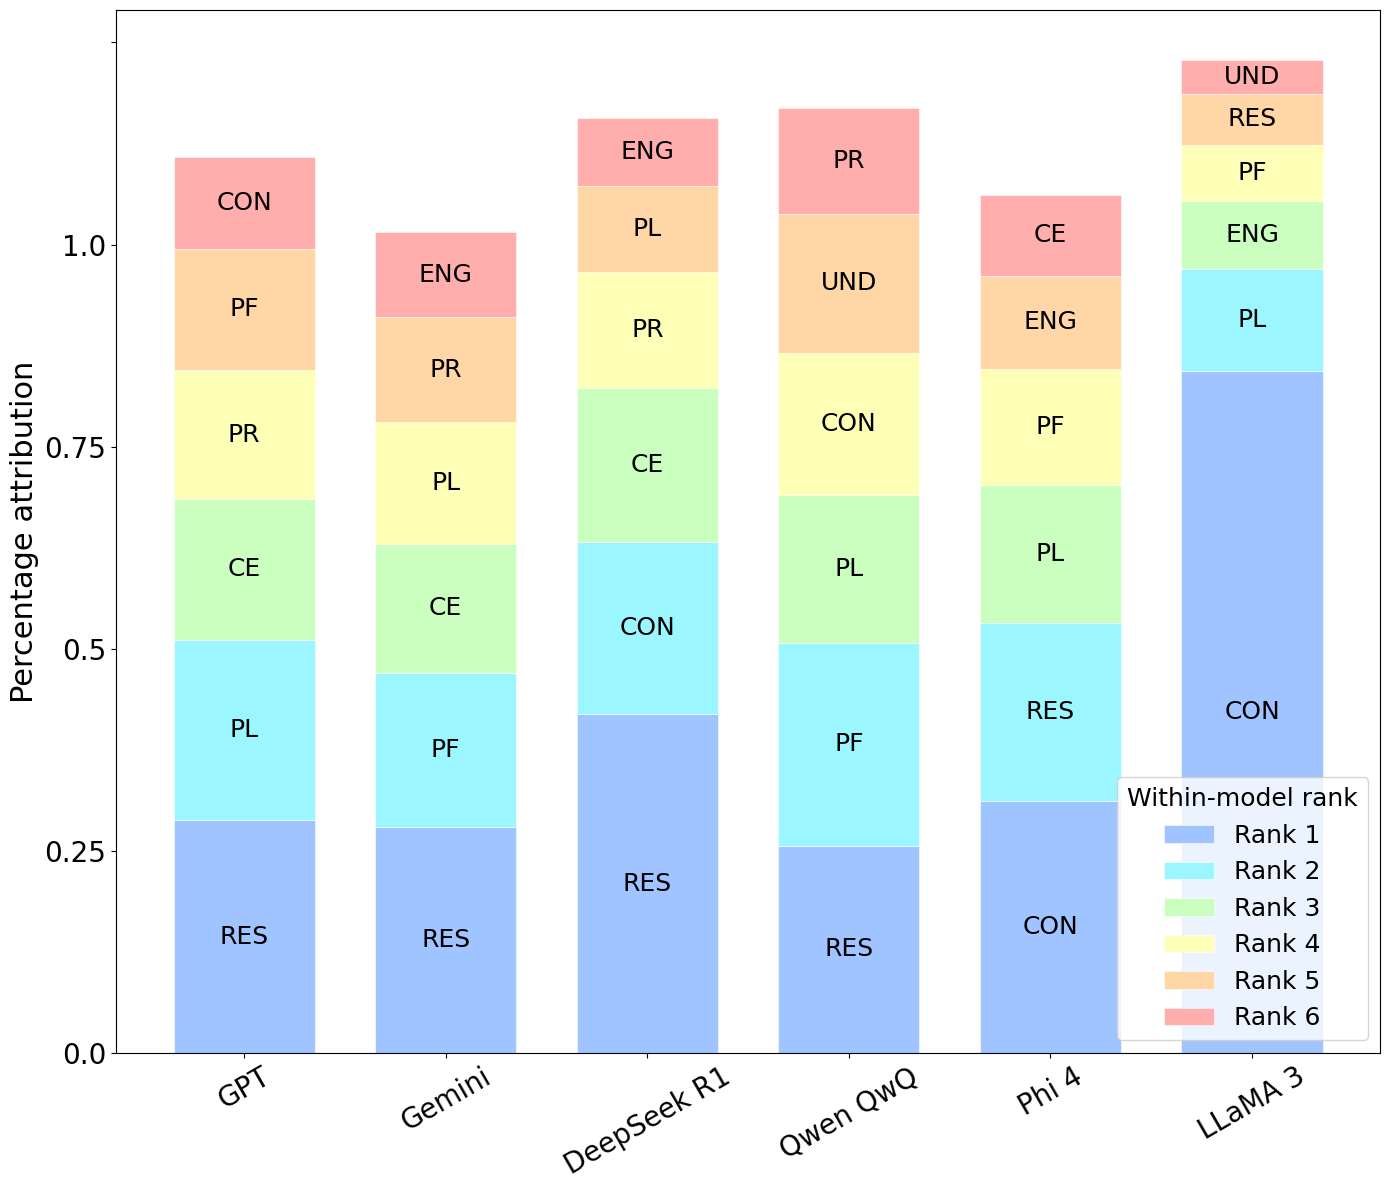

In [14]:
model_dicts = {
    "GPT": gpt_dict_clubbed, 
    "Gemini": gemini_dict_clubbed, 
    "DeepSeek R1": ds_dict_clubbed, 
    "Qwen QwQ": qwq_dict_clubbed, 
    "Phi 4": phi_dict_clubbed,
    "LLaMA 3": llama_dict_clubbed
}

# colors = ["#f94144", "#f3722c", "#f8961e", "#f9c74f", "#90be6d", "#43aa8b"]
colors = ["#A0C4FF", "#9BF6FF", "#CAFFBF", "#FDFFB6", "#FFD6A5", "#FFADAD", "#f0f3bd"]

TOP_K = 6
# Same colors by rank across bars (rank-1..rank-6)
rank_colors = [plt.cm.tab10(i) for i in range(TOP_K)]  # feel free to swap palette
# Minimum height to draw a text label (avoids clutter)
LABEL_MIN_HEIGHT = 0.03  # tweak to taste

# Optional custom abbreviations (fallback = smart initials)
abbr_map = {
    'responsibility': "RES",
    'control': "CON", 
    'pleasantness': 'PL',
    'engagement': "ENG",
    'problem': 'PR',
    'certainty': 'CE',
    'effort': 'EF',
    'fairness': 'PF',
    'understand': 'UND'
}

def short_label(name: str) -> str:
    if name in abbr_map:
        return abbr_map[name]
    # fallback: compress to capitalized initials or shortened tokens
    toks = [t for t in name.replace('-', ' ').split() if t.strip()]
    if len(toks) == 1:
        return toks[0][:6].capitalize()
    return ''.join(w[0].upper() for w in toks)  # initials

# --------------------------
# Prepare rank-based stacks
# --------------------------
models = list(model_dicts.keys())
n_models = len(models)

# For each model, get its top-K (sorted descending), keep names and values
rank_names = [[] for _ in range(TOP_K)]   # rank_names[r][m] = dim name at rank r for model m
rank_vals  = [[] for _ in range(TOP_K)]   # rank_vals[r][m]  = value at rank r for model m

for m in models:
    d = model_dicts[m]
    top = sorted(d.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    # If fewer than K keys exist, pad with (None, 0.0)
    if len(top) < TOP_K:
        top += [("—", 0.0)] * (TOP_K - len(top))
    # top[0] is rank-1 (largest)
    for r in range(TOP_K):
        rank_names[r].append(top[r][0])
        rank_vals[r].append(top[r][1])
    
# --------------------------
# Plot (stacked by rank, rank-6 bottom ... rank-1 top)
# --------------------------
x = np.arange(n_models)
width = 0.7

fig, ax = plt.subplots(figsize=(14, 12))
bottom = np.zeros(n_models)

# Draw from lowest rank to highest so that rank-1 ends up on top
for r in range(TOP_K):
    vals = np.array(rank_vals[r])
    bars = ax.bar(x, vals, width, bottom=bottom, color=colors[r],
                  edgecolor='white', linewidth=0.4,
                  label=f"Rank {r+1}")
    # Text labels for this rank
    for i, bar in enumerate(bars):
        h = bar.get_height()
        if h >= LABEL_MIN_HEIGHT:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[i] + h/2,
                    short_label(rank_names[r][i]),
                    ha='center', va='center', fontsize=18)
    bottom += vals

# Axes/legend/labels
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=20, rotation=30)
ax.set_ylabel("Percentage attribution", fontsize=22)
ax.set_yticklabels(np.linspace(0, 1.0, 5).tolist(), fontsize=20)
# ax.set_title(f"Top Explicitly Chosen Appraisal Dimensions", fontsize=20)
# Legend shows the rank->color mapping
# ax.legend(title="Within-model rank", bbox_to_anchor=(1.02, 1), loc="upper left")
legend = ax.legend(title="Within-model rank", title_fontsize=18, loc="best", ncol=1, frameon=True, fontsize=18)
plt.tight_layout()
plt.savefig("./results_new/explicit_reasoning.pdf", format="pdf", bbox_inches="tight")
plt.show()

Observations for each of the models: 
1. GPT: does not report pleasantness, or problem too frequently. Does not report Effort at all. Is aligned the most for responsibility, problem still reported. Reports certainty quite often, although implicitly not reported/seen. 

2. Gemini: Reports responsibility pretty frequently. Reports perceived fairness frequently, which is not seen in the implicit responses. Effort reported very less, which is major in implicit responses. Problem is also reported less frequently. 

3. DeepSeek R1: Again reports responsibility very frequently. Does not report effort at all. Reports problem less frequently. Certainty reported frequently again. 

4. QwQ: perceived fairness reported highly, and seen in the implicit results too. First case of a match. Responsibiility again reported frequently. Pleasantness is the next most frequent, which is not seen in its implicit results. Problem again reported less frequently. 

5. Phi 4: again reports responsibility very highly. Does not report Problem, Pleasantness or effort at all. Reports perceived fairness quite frequently, although it is not seen in the implicit data. Control is also reported relatively more frequently. 

6. LLama 3: Control is considered the most frequent for llama, including both self and situational control. Pleasantness (enjoyment), engagement, and perceived fairness reported relatively less frequently (ENJ).